## Libraries & Function

In [28]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
from qutip import *
from IPython.display import Image, display, Math

In [29]:
#funzione per plottare in LaTex delle matrici
def array_to_latex(array, real = False, array_name = None):
    array = array.real if real else array
    matrix = ''
    for row in array:
        try:
            for number in row:
                matrix += f'{number}&'
        except TypeError:
            matrix += f'{row}&'
        matrix = matrix[:-1] + r'\\'
    if array_name != None:
        display(Math(array_name+r' = \begin{bmatrix}'+matrix+r'\end{bmatrix}'))
    else:
        display(Math(r'\begin{bmatrix}'+matrix+r'\end{bmatrix}'))

### Lindblad functions

In [30]:
 def Liouvillian(H: np.ndarray,
                gamma_k: list,
                L_k: list):
    
     I = np.eye(H.shape[0])  #creo matrice identità delle diemnsioni adatte
     super_L = -1.j * (np.kron(I, H) - np.kron(H.T, I))  #Dissipatore di Lindblad
    
     for k in range(len(gamma_k)):
        super_L += gamma_k[k] * (np.kron(np.conj(L_k[k]), L_k[k]) - 0.5 * np.kron(I, np.conj(L_k[k]).T @ L_k[k]) - 0.5 * np.kron((np.conj(L_k[k]).T @ L_k[k]).T, I))

     return super_L


In [31]:
def Lindblad_evo(rho, H, gamma_k, L_k, t_list, method="U", vectorized=True):
    """
    Evolution of the density matrux with the Linblad Eq.
    
    Method: "U" -> propagator = expm(super_L * dt) (needs L_k as NumPy array)
            "diagonal" -> diagonalizzation of the super-op. (needs L_k as NumPy array )
            "qutip" -> using mesolve from QuTiP (needs L_k as Qobj)
    Vectorized: True/False to choose the output format
    
    Output:
            - if vectorized=True → array (N^2, Nt)
            - if vectorized=False → array (Nt, N, N)
       
    """
    N = H.shape[0]
    dt = t_list[1] - t_list[0]
    
    # ===============================
    #   U & DIAGONAL METHODS
    # ===============================
    if method in ["U", "diagonal"]:
        # Converts Qobj in NumPy array 
        L_k_num = [L.full() if hasattr(L, "full") else np.array(L) for L in L_k]
        H_num = H.full() if hasattr(H, "full") else np.array(H)
        rho_num = rho.full() if hasattr(rho, "full") else np.array(rho)
        
        # Build up of the Lindbladian
        super_L = Liouvillian(H_num, gamma_k, L_k_num)
        
        # Vectorized intial state
        rho_vec = rho_num.reshape(N*N)
        
        # Result array inizialized
        rho_vec_list = np.zeros((N*N, len(t_list)), dtype=complex)
        rho_vec_list[:, 0] = rho_vec
        
        # Time Propagator
        if method == "U":
            super_U = expm(super_L * dt)
            
            # Evolution
            for i in range(1, len(t_list)):
                rho_vec_list[:, i] = super_U @ rho_vec_list[:, i - 1]
            
            # Output
            if vectorized:
                return rho_vec_list  # (N^2, Nt)
            else:
                return rho_vec_list.T.reshape(len(t_list), N, N)  # (Nt, N, N)
                
        elif method == "diagonal":
            #Diagobalization of the Super-Op.
            W, V = np.linalg.eig(super_L)
            # Converts in NumPy array
            W = np.array(W)  #Eigenenergies
            V = np.array(V)  #Eigenvectors

            # Build up of the Diagonal Lindbladian
            U_diag = np.diag(np.exp(W * dt))
            super_U = V @ U_diag @ np.linalg.inv(V)
            
            # Evolution
            for i in range(1, len(t_list)):
                rho_vec_list[:, i] = super_U @ rho_vec_list[:, i - 1]
            
            # Output with Eigenenergies & Eigenvectors (as NumPy array)
            if vectorized:
                return rho_vec_list, V, W  # (N^2, Nt), (N^2, N^2), (N^2,)
            else:
                return rho_vec_list.T.reshape(len(t_list), N, N), V, W  # (Nt, N, N), (N^2, N^2), (N^2,)
    
    # ===============================
    #   QUTIP METHOD
    # ===============================
    elif method == "qutip":
        H_qobj = Qobj(H) if not hasattr(H, "full") else H
        rho_qobj = Qobj(rho) if not hasattr(rho, "full") else rho
        
        # Build up of the collapse operators
        c_ops = []
        for g, L in zip(gamma_k, L_k):
            if g != 0:
                L_qobj = L if hasattr(L, "full") else Qobj(L)
                c_ops.append(np.sqrt(g) * L_qobj)
        
        # Evolution with mesolve
        result = mesolve(
            H_qobj,
            rho_qobj,
            t_list,
            c_ops=c_ops,
            options={"store_states": True},
        )
        
        # Converts the QuTiP eigenstates in vectorized NumPy array.
        rho_vec_list = np.zeros((N*N, len(t_list)), dtype=complex)
        for i, rho_t in enumerate(result.states):
            rho_vec_list[:, i] = rho_t.full().reshape(N*N)
        
        # Output
        if vectorized:
            return rho_vec_list
        else:
            return rho_vec_list.T.reshape(len(t_list), N, N)
    
    else:
        raise ValueError("Set 'U', 'diagonal' or 'qutip'.")

### Collisional Method functions

In [45]:
def system_Hamiltonian(E, V, mode="full"):
    N = len(E)

    # Exciton subspace
    if mode == "exc":   
        H_sys = np.zeros((N, N), dtype=complex)
        for i in range(N):
            H_sys[i, i] = E[i]
        for i in range(N):
            for j in range(N):
                if i != j:
                    H_sys[i, j] = V
        return H_sys
        
    # Complete Hamiltonian    
    elif mode == "full":   
        dim = 2**N
        H_sys = np.zeros((dim, dim), dtype=complex)

        for i in range(N):
            H_i = (E[i]/2) * tensor(identity(2**i), identity(2)-sigmaz(), identity(2**(N-i-1)))  # g states have 0 energy and the e sites have all the energy
            #H_i = (E[i]/2) * tensor(identity(2**i), sigmaz(), identity(2**(N-i-1)))   # To be the same as eq II.18, where g and e state has the sameenergy but with different sign, as like the DE between the two states is equal to excoted state energy
            
            H_sys += H_i.full()

            for j in range(i+1, N):
                H_ij = (V/2) * (tensor(identity(2**i), sigmax(), identity(2**(j-i-1)), sigmax(), identity(2**(N-j-1))) + tensor(identity(2**i), sigmay(), identity(2**(j-i-1)), sigmay(), identity(2**(N-j-1))))
                H_sys += H_ij.full()
        return H_sys

    else:
        raise ValueError("mode has to be 'full' or 'exc'")


In [33]:
def interaction_Hamiltonian_N_ancillas(N, c_list):   #Hamiltonian of interaction with N different ancillas, one for every site of the system

    H_int = 0   #inizialization

    for j in range(N):
  
        op_list = [identity(2) for _ in range(2 * N)]  #list of identity to be fill with the operator sigmaz & sigmax; 2N idensitty, N for the system and N fo the ancillas
        
        op_list[j] = sigmaz()      # Acts on the j site
        op_list[N + j] = sigmax()  # Acts on the j ancilla, with index N + j
        
        H_term = c_list[j] * tensor(op_list)  # tensor product between the element of the list
        H_int += H_term

    return H_int


In [73]:
def hamiltonian_N_ancillas(N, E, V, c_list, method="complete"):
    """
    Generation of 3 Hamiltonians for the collision model with N ancillas:
        - H_system : system Hamiltonian
        - H_collision : interaction Hamiltonian with N ancillas
        - H_tot : complete Hamiltonian (system + collision)
    
    Method : - complete : both excited and ground states
             - excited : only excited states
    """
    
    if method == "complete":
        # ==============
        # Complete Basis 
        # ==============

        H_system_np = system_Hamiltonian(E, V, mode="full")
        H_system = Qobj(H_system_np, dims=[[2]*N, [2]*N])
        
        H_collision = interaction_Hamiltonian_N_ancillas(N, c_list)
        
        Id_ancillas = tensor([identity(2) for _ in range(N)])
        H_tot = tensor(H_system, Id_ancillas) + H_collision
        
        return H_system, H_collision, H_tot
        
    elif method == "excited":
        # =========================
        # Only Excited States Basis
        # =========================
        
         H_system = Qobj(system_Hamiltonian(E, V, mode="exc"))
        
         H_collision = 0
         for j in range(N):
            diag_vals = np.ones(N)
            diag_vals[j] = -1 
            Z_sys_j = Qobj(np.diag(diag_vals))
            
            anc_ops = [identity(2) for _ in range(N)]
            anc_ops[j] = sigmax()
            X_anc_j = tensor(anc_ops)
            
            H_collision += c_list[j] * tensor(Z_sys_j, X_anc_j)
        
         Id_ancillas = tensor([identity(2) for _ in range(N)])
         H_tot = tensor(H_system, Id_ancillas) + H_collision
        
         return H_system, H_collision, H_tot
        
    else:
         raise ValueError("method has to be 'complete' or 'excited'")

In [59]:
def hamiltonian_lists_1_ancilla (N, E, V, c_list, method="complete"):
    """
    Generation of 3 list to build up the evolution algorithm:
        - H_site_list : contains the energy of each site
        - H_potential_list : contains the interaction potential coupled between two sites in a "all-to-all" interaction system
        - H_collisional_list : contains th interaction with the single ancilla for every site; the ancilla has to be resetted after the collsion with one site
    Method : - complete : take into account both the excited and ground states for every sites
             -  excited : take into account only the excited state for every sites  
    """
    H_site_list = []
    H_potential_list = []
    H_collisional_list = []

    if method == "complete":
        # ==============
        # Complete Basis 
        # ==============
        
        # Single site hamiltonian
        for i in range(N):
             H_site_list.append((E[i] * (identity(2) - sigmaz()) / 2).full())    # matrix with dimension 2x2

        # Potential interaction
        for i in range(N):
            for j in range(i + 1, N):
                H_potential_ij = ((V/2) * (tensor(sigmax(), sigmax()) + tensor(sigmay(), sigmay()))).full()  # matrix with dimension 4x4
                H_potential_list.append(((i, j), H_potential_ij))   

        # Collisional Hamiltonian
        for i in range(N):
            H_collisional_list.append((c_list[i] * (tensor(sigmaz(), sigmax()))).full())  # matrix with dimension 4x4 (Site + Ancilla)

    elif method == "excited":
        # =========================
        # Only Excited States Basis
        # =========================
        
        # Single site hamiltonian
        for i in range(N):
             H_site_list.append(np.array([[E[i]]]))  # matrix with dimension 1x1

        # Potential interaction
        for i in range(N):
            for j in range(i + 1, N):
                H_potential_ij = (V * (sigmax())).full()    # matrix with dimension 2x2
                H_potential_list.append(((i, j), H_potential_ij))

        # Collisional Hamiltonian
        for target_site in range(N):
            diag_values = np.ones(N)
            diag_values[target_site] = -1.0  
            Z_eff = Qobj(np.diag(diag_values)) # Z_eff denotes in which state we are applying the collison
            
            H_coll = (c_list[target_site] * tensor(Z_eff, sigmax())).full()   # matrix with dimension 2Nx2N
            H_collisional_list.append(H_coll)
            
    else:
        raise ValueError("method has to be 'complete' or 'excited'")

    return H_site_list, H_potential_list, H_collisional_list

# Case of study : Excitonic Dimer
## Lindblad Evolution
We will study the dynamic rappresented with a Lindblad equation of the densit matrix of an excitonic dimer, focusing only on the two excited states. <br>
We'll use an initial density matrix which only has population in the first site: $ \rho (0)  = \begin{bmatrix}1 & 0 \\ 0 & 0 \\\end{bmatrix} $ <br>
First of all we will focus only on the exciton tranfer between the two dimers, so the Jump Operator has this form: $$ \mathcal{L}_{1\rightarrow2} = \ket{e_2}\bra{e_1} \; ; \; \mathcal{L}_{2\rightarrow1} = \ket{e_1}\bra{e_2} $$ 
So that the Dissipator gives:
$$ \mathcal{L}_{1\rightarrow2}\rho_{11}\mathcal{L}_{1\rightarrow2}^\dagger = \ket{e_2}\bra{e_1}\ket{e_1}\bra{e_1}\ket{e_1}\bra{e_2} = \ket{e_2}\bra{e_2} = \rho_{22} $$  
$$ \frac{1}{2} \mathcal{L}_{1\rightarrow2}^\dagger\mathcal{L}_{1\rightarrow2}\rho_{11} = \frac{1}{2} \ket{e_1}\bra{e_2}\ket{e_2}\bra{e_1}\ket{e_1}\bra{e_1} = \frac{1}{2} \ket{e_1}\bra{e_1} = \frac{1}{2}\rho_{11} $$  
$$ \frac{1}{2} \rho_{11}\mathcal{L}_{1\rightarrow2}^\dagger\mathcal{L}_{1\rightarrow2} = \frac{1}{2} \ket{e_1}\bra{e_1}\ket{e_1}\bra{e_2}\ket{e_2}\bra{e_1} = \frac{1}{2} \ket{e_1}\bra{e_1} = \frac{1}{2}\rho_{11} $$ 
and the same for the evolution of $ \rho_{22} $

In [50]:
#System definition
dt = 0.01; t_list = np.arange(0, 100 + dt, dt)
N = 2 # number of sites
E = 1.5 + np.random.randn(N)*0.1   #random inizialization of the system energies {con energia pari a 1.5 ± numero casuale estratto da distribuzione con media 0 e varianza 0.01}
V = 0.1   # Interaction Potential
# Base: |00>, |10>, |01>, |11>
H_tot = np.array ( [ [0, 0, 0, 0],
                     [0, E[1], V, 0],
                     [0, V, E[0], 0],
                     [0, 0, 0, E[1]+E[0]] ] )
#Hamiltonian
H = np.array ([ [E[1], V],     
                [ V, E[0] ] ] , dtype = complex)

#Density Matrix
rho = np.array([[1.0, 0.0],
                [0.0, 0.0]], dtype=complex)

#Jump Oerator
L_k = [sigmap().full(), sigmam().full(), ]  #change this to use H_tot
#Rates
gamma_1 = 0.1 ; gamma_2 = 0.1
gamma_k = [gamma_2, gamma_1]

Super_L = Liouvillian(H, gamma_k, L_k)

array_to_latex(H, array_name=r'\mathcal{H}') , array_to_latex(Super_L, array_name=r'\mathcal{L}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

(None, None)

In [51]:
# Evolution with diagonalization of the Lindbaldian operator
rho_list_diag, V, W = Lindblad_evo(rho, H, gamma_k, L_k, t_list, method="diagonal")

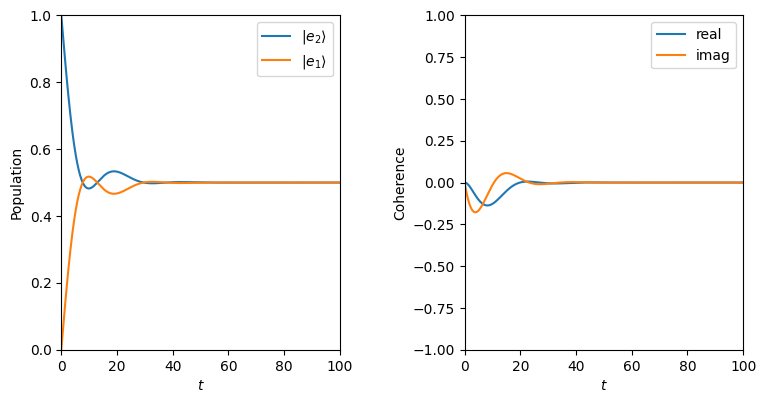

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(t_list, np.real(rho_list_diag[0, :]), label=r'$| e_2 \rangle$')
ax1.plot(t_list, np.real(rho_list_diag[3, :]), label=r'$| e_1 \rangle$')
ax1.set_xlim(0, t_list[-1]); ax1.set_ylim(0, 1); ax1.set_xlabel(r'$t$'); ax1.set_ylabel('Population'); ax1.legend()
ax2.plot(t_list, np.real(rho_list_diag[1, :]), label='real')
ax2.plot(t_list, np.imag(rho_list_diag[1, :]), label='imag')
ax2.set_xlim(0, t_list[-1]); ax2.set_ylim(-1, 1); ax2.set_xlabel(r'$t$'); ax2.set_ylabel('Coherence'); ax2.legend()
fig.tight_layout(); fig.set_size_inches(8, 4); fig.set_dpi(100)

In [53]:
array_to_latex(V)

<IPython.core.display.Math object>

In [54]:
array_to_latex(W)

<IPython.core.display.Math object>

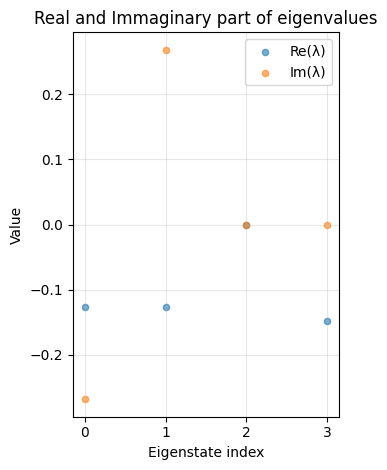

In [55]:
# Plot of the eigenvalues with separated real and immaginary part
plt.subplot(1, 2, 2)
idx = np.arange(len(W))
plt.scatter(idx, W.real, alpha=0.6, s=20, label='Re(λ)')
plt.scatter(idx, W.imag, alpha=0.6, s=20, label='Im(λ)')
plt.xlabel('Eigenstate index')
plt.ylabel('Value')
plt.title('Real and Immaginary part of eigenvalues')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Collisional Method
### Quantum Jump / Monte Carlo limit
The goal is to reproduce the Lindbald dynamic seen above using a Collsional Model, that gives us a trajectory of evolution of a single state of the density matrix $ \ket{\Psi_k} $ rappresentig a qubit. By repeting the dynamic several times it's possibile to recrate the Linbald evolution of the density matrix.
Different unravelling of the $ \rho (t) $ can be achieved by using different Collsional Hamiltonian. First we will reproduce the so called "Quantum Jump" or "Monte Carlo" imit, in which essentialy the states stochastically jumps between the states $ \ket{0} $ and $ \ket{1} $ with a small probability to move to $ \ket{1} $. <br> 
The associated Hamiltonian acting on the System-Ancilla states is:
$$ \mathcal{H}_{CM} = \mathcal{H}_{exc} \otimes \mathbb{I}^{\otimes N} + \mathcal{H}_{collision} $$ 
$$ = \sum_{j=1}^{N} {\frac{\varepsilon_j}{2} \sigma_{z}^{j} \otimes \mathbb{I}^{\otimes N} } + \sum_{\langle j,j' \rangle} {\frac{V_{j,j'}}{2} \left( \sigma_{x}^{j}\sigma_{x}^{j'} \otimes \mathbb{I}^{\otimes N} + \sigma_{y}^{j}\sigma_{y}^{j'} \otimes \mathbb{I}^{\otimes N} \right)} + \sum_{j=1}^{N}{c_j \sigma_{z}^{j} \otimes \sigma_{x}^{a_j}} $$
where $ \sigma_{\alpha}^j = \mathbb{I}^{\otimes j-1} \otimes \sigma_{\alpha} \otimes \mathbb{I}^{\otimes N-j}  $ .<br>
Let's focus on the Interaction Hamiltonian and how it acts on an already enatgled system-ancilla states $ \ket{\Psi} = \ket{\Psi_S} \otimes \ket{0_a} $ <br>
The evolution operator based on $ \mathcal{H}_{collsional} $ is : $$ U_{collsional} = \exp \left(-i c_j \sigma_{z}^{j} \otimes \sigma_{x}^{a_j} \Delta t\right) = \cos \left(c_j \Delta t \right) \mathbb{I}^j \otimes \mathbb{I}^a - i \sin \left(c_j \Delta t \right) \sigma_{z}^{j} \otimes \sigma_{x}^{a_j} $$
And applied to $ \ket{\Psi} $ gives:
$$ \begin{align} 
\ket{\Psi'} &= \cos \left(c_j \Delta t \right) \mathbb{I}^j \otimes \mathbb{I}^a \ket{\Psi} - i \sin \left(c_j \Delta t \right) \sigma_{z}^{j} \otimes \sigma_{x}^{a} \ket{\Psi} \\
&= \cos \left(c_j \Delta t \right) \ket{\Psi_S} \otimes \ket{0_a} - i \sin \left(c_j \Delta t \right) \sigma_{z}^{j} \ket{\Psi_S} \otimes \sigma_{x}^{a} \ket{0_a} \\
&= \cos \left(c_j \Delta t \right) \ket{\Psi_S} \otimes \ket{0_a} - i \sin \left(c_j \Delta t \right) \sigma_{z}^{j} \ket{\Psi_S} \otimes \ket{1_a}
\end{align} $$
By measuring the Ancilla's state we can deduce if we had an avoided collision $ \ket{0_a} $ or an occurred collision $ \ket{1_a} $, which imples the application to the system of $ \sigma_{z}^{j} \ket{\Psi_S} $ which introduce a flip in the phase of the interacting site, with a probability of $ \left| {\sin \left(c_j \Delta t \right)} \right|^2  $, which contributes to the site dephasing process, helping the excitonic tranport (ENAQT - Enviroment Assisted Quantum Transport). <br>
Measuring repeted time $ s $ the Ancilla states correspond on racing its states out, so that we could rebuild the density matrix as 
$$ \rho_S = \left| c_0 \right| ^2 \ket{\Psi_{0,S}}\bra{\Psi_{0,S}} + \left| c_1 \right|^2 \ket{\Psi_{1,S}}\bra{\Psi_{1,S}} $$ where $ c_0 \propto \cos \left(c_j \Delta t \right)  $ and $ c_1 \propto \sin \left(c_j \Delta t \right) $ <br>
<br>
Let's first define the Hamiltonian $ \mathcal{H}_{CM} $ using a single ancilla $ a_j $ for every $ j $ site of the system. With the collsion the the site and the ancilla get in a state like $ \ket{\Psi} = \ket{\Psi_{\mathcal{S}}} \otimes \ket{a} $ . <br>
If we consider the complete sistem, with both ground and excited states for every site the associated Hilbert space has dimension equal to : $ dim = 2^N \times 2^N = 2^{2N}  $ and the Hamiltonian has the form :

In [74]:
# Hamiltonian for N ancillas interacting
dt = 0.01; t_list = np.arange(0, 100 + dt, dt)
N = 2        # number of sites 
E = 1.5 + np.random.randn(N)*0.1     #random inizialization of the system energies {con energia pari a 1.5 ± numero casuale estratto da distribuzione con media 0 e varianza 0.01}
V = 0.1     # Interaction Potential
c_list = [0.2, 0.5] # coupling strenght different for every site
array_to_latex(E)

# Base: |00>, |10>, |01>, |11>
H_exc, H_coll, H_CM_complete = hamiltonian_N_ancillas(N, E, V, c_list, method="complete")

array_to_latex(H_exc.full(), array_name=r'\mathcal{H_exc}')

H_sites = (tensor(H_exc, identity(2**N))).full()
#array_to_latex(H_sites, array_name=r'\mathcal{H_sites}')

#array_to_latex(H_coll.full(), array_name=r'\mathcal{H_coll}')

array_to_latex(H_CM_complete.full(), array_name=r'\mathcal{H_CM}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

We could consider only the excited states between which the exciton transfer takes place and again an ancilla for every site. In this case the Hilbert space has $ dim = N \times 2^N $

In [75]:
H_exc, H_coll, H_CM_exc = hamiltonian_N_ancillas(N, E, V, c_list, method="excited")
array_to_latex(H_CM_exc.full(), array_name=r'\mathcal{H}_{CM exc}')

<IPython.core.display.Math object>

Once we defined the $ \mathcal{H}_{CM} $ we can build up the Evolution Operator for a small time step $ \Delta t $ as : $ U = \exp \left( -i \mathcal{H}_{CM} \Delta t \right) $. To simplify we can apply the Trotter-Suzuki decomposition and get : $$ \begin{align}
U &= \exp \left\{ -i \left[ \sum_{j=1}^{N} {\frac{\varepsilon_j}{2} \sigma_{z}^{j} \otimes \mathbb{I}^{\otimes N} } + \sum_{\langle j,j' \rangle} {\frac{V_{j,j'}}{2} \left( \sigma_{x}^{j}\sigma_{x}^{j'} \otimes \mathbb{I}^{\otimes N} + \sigma_{y}^{j}\sigma_{y}^{j'} \otimes \mathbb{I}^{\otimes N} \right)} + \sum_{j=1}^{N}{c_j \sigma_{z}^{j} \otimes \sigma_{x}^{a_j}}  \right] \Delta t \right\} \\
&\approx \left( e^{-i \frac{\Delta t}{m} \sum_{j=1}^{N} {\frac{\varepsilon_j}{2} \sigma_{z}^{j} \otimes \mathbb{I}^{\otimes N}}} e^{-i \frac{\Delta t}{m} \sum_{\langle j,j' \rangle} {\frac{V_{j,j'}}{2} \left( \sigma_{x}^{j}\sigma_{x}^{j'} \otimes \mathbb{I}^{\otimes N} + \sigma_{y}^{j}\sigma_{y}^{j'} \otimes \mathbb{I}^{\otimes N} \right)}} e^{-i \frac{\Delta t}{m} \sum_{j=1}^{N}{c_j \sigma_{z}^{j} \otimes \sigma_{x}^{a_j}}} \right)\\
&= \left( \prod_{j=1}^{N} {e^{-i \frac{\Delta t}{m} \frac{\varepsilon_j}{2} \sigma_{z}^{j}}} \prod_{\langle j,j' \rangle} {e^{-i \frac{\Delta t}{m} \frac{V_{j,j'}}{2} \left( \sigma_{x}^{j}\sigma_{x}^{j'} + \sigma_{y}^{j}\sigma_{y}^{j'} \right)}} \prod_{j=1}^{N} {e^{-i \frac{\Delta t}{m} \frac{\varepsilon_j}{2} \sigma_{z}^{j}}} \right)^m + \mathcal{O} \left( \frac {\Delta t ^2}{m^2} \right)
\end{align} $$
As the collision model is shown to converge to the solution of the
Lindblad master equation in the limit of small collision time $ \Delta t $, a small error is obtained with just $ m = 1 $. <br>
Thanks to the T-S approximation we can semplify the collisoinal algorithm which doesn't no longer include an ancilla for every site, but we can use a single ancilla which gets resetted after every collision with a site $ j $ ; this is possible because in the T-S approx we can see thata every collsion with a site is indipendent from the other sites. <br>
This semplification requires a new circuit of evolution and a new hamiltonian to be implemented; to achieve maximum computational gain we'll define the Hamiltonian in the: <br> 
<ul>
    <li> complete basis : we consider both the ground and excited states for every site
    <li> only excited states basis : we consider only the excited states for every site
</ul>

In [76]:
# complete basis
H_site, H_potential, H_collisional = hamiltonian_lists_1_ancilla (N, E, V, c_list, method="complete")

In [77]:
H_site_exc, H_potential_exc, H_collisional_exc = hamiltonian_lists_1_ancilla (N, E, V, c_list, method="excited")